# **Predicción de Abandono de Clientes Bancarios mediante Regresión Logística**

z = β₀ + β₁x₁ + β₂x₂ + ... + βnxn

P(Y=1) = 1 / (1 + e⁻ᶻ)

In [114]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

**CARGA DEL DATASET**(CUSTOMER-CHURN

In [130]:
df = pd.read_csv("Customer-Churn-Records.csv")

df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1,2,DIAMOND,464
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,1,3,DIAMOND,456
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1,3,DIAMOND,377
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0,5,GOLD,350
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0,5,GOLD,425


In [131]:
print("Dimensiones:")
print(df.shape)

print("\nInformación:")
print(df.info())

print("\nValores nulos:")
print(df.isnull().sum())

Dimensiones:
(10000, 18)

Información:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   RowNumber           10000 non-null  int64  
 1   CustomerId          10000 non-null  int64  
 2   Surname             10000 non-null  object 
 3   CreditScore         10000 non-null  int64  
 4   Geography           10000 non-null  object 
 5   Gender              10000 non-null  object 
 6   Age                 10000 non-null  int64  
 7   Tenure              10000 non-null  int64  
 8   Balance             10000 non-null  float64
 9   NumOfProducts       10000 non-null  int64  
 10  HasCrCard           10000 non-null  int64  
 11  IsActiveMember      10000 non-null  int64  
 12  EstimatedSalary     10000 non-null  float64
 13  Exited              10000 non-null  int64  
 14  Complain            10000 non-null  int64  
 15  Satisfaction Sc

verificamos variables

In [129]:
coeficientes = pd.DataFrame({
    'Variable': X.columns,
    'Coeficiente': modelo.coef_[0]
})

coeficientes = coeficientes.sort_values(
    by='Coeficiente',
    ascending=False
)

print(coeficientes)

              Variable  Coeficiente
8             Complain     5.079569
1                  Age     0.811609
16    Card Type_SILVER     0.113615
12     Geography_Spain     0.112248
3              Balance     0.068459
0          CreditScore     0.033418
5            HasCrCard    -0.013653
2               Tenure    -0.063530
7      EstimatedSalary    -0.075629
4        NumOfProducts    -0.126078
13         Gender_Male    -0.147459
14      Card Type_GOLD    -0.166839
9   Satisfaction Score    -0.213679
11   Geography_Germany    -0.220424
15  Card Type_PLATINUM    -0.235249
10        Point Earned    -0.329617
6       IsActiveMember    -0.560005


ELIMINAR COLUMNAS INNECESARIOS PARA EL PROBLEMA

In [132]:
df = df.drop(columns=["Complain"])

In [133]:
df = df.drop(
    columns=[
        "RowNumber",
        "CustomerId",
        "Surname"
    ]
)

Convertir variables categóricas

In [134]:
df = pd.get_dummies(
    df,
    columns=[
        "Geography",
        "Gender",
        "Card Type"
    ],
    drop_first=True
)

Separar X e Y

In [135]:
X = df.drop("Exited", axis=1)

y = df["Exited"]

ENTRENAMIENTO

In [136]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

ESCALADO

In [137]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

REGRESION LOGISTICA

In [138]:
modelo = LogisticRegression(
    max_iter=1000
)

modelo.fit(
    X_train,
    y_train
)

LogisticRegression(max_iter=1000)

PREDICCION

In [139]:
y_pred = modelo.predict(X_test)

EVALUACION

In [140]:
print("Accuracy:")

print(
    accuracy_score(
        y_test,
        y_pred
    )
)

print("\nMatriz de Confusión:")

print(
    confusion_matrix(
        y_test,
        y_pred
    )
)

print("\nReporte:")

print(
    classification_report(
        y_test,
        y_pred
    )
)

Accuracy:
0.811

Matriz de Confusión:
[[1542   65]
 [ 313   80]]

Reporte:
              precision    recall  f1-score   support

           0       0.83      0.96      0.89      1607
           1       0.55      0.20      0.30       393

    accuracy                           0.81      2000
   macro avg       0.69      0.58      0.59      2000
weighted avg       0.78      0.81      0.77      2000



EJEMPLO

In [141]:
nuevo_cliente = pd.DataFrame({
    'CreditScore': [450],
    'Age': [60],
    'Tenure': [1],
    'Balance': [150000],
    'NumOfProducts': [1],
    'HasCrCard': [1],
    'IsActiveMember': [0],
    'EstimatedSalary': [30000],
    'Satisfaction Score': [1],
    'Point Earned': [100],
    'Geography_Germany': [1],
    'Geography_Spain': [0],
    'Gender_Male': [1],
    'Card Type_GOLD': [0],
    'Card Type_PLATINUM': [0],
    'Card Type_SILVER': [1]
})

In [142]:
nuevo_cliente_scaled = scaler.transform(nuevo_cliente)

prediccion = modelo.predict(nuevo_cliente_scaled)

probabilidad = modelo.predict_proba(nuevo_cliente_scaled)

print("Resultado:")

if prediccion[0] == 1:
    print("El cliente abandonará el banco.")
else:
    print("El cliente permanecerá en el banco.")

print(f"Probabilidad de abandono: {probabilidad[0][1]*100:.2f}%")

Resultado:
El cliente abandonará el banco.
Probabilidad de abandono: 78.25%


distribucion de clientes que permanecen o abandonan

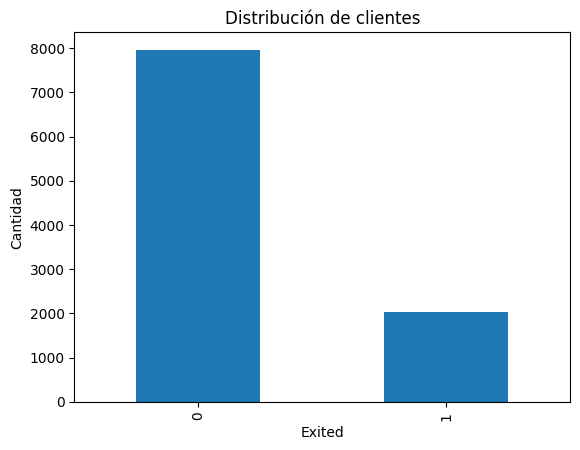

In [ ]:
import matplotlib.pyplot as plt

df["Exited"].value_counts().plot(kind="bar")

plt.title("Distribución de clientes")
plt.xlabel("Exited")
plt.ylabel("Cantidad")
plt.show()

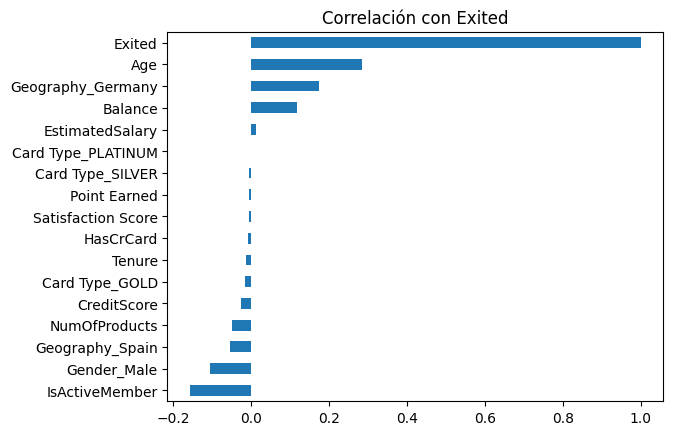

In [143]:
import matplotlib.pyplot as plt

correlaciones = df.corr(numeric_only=True)["Exited"]

correlaciones.sort_values().plot(kind="barh")

plt.title("Correlación con Exited")

plt.show()

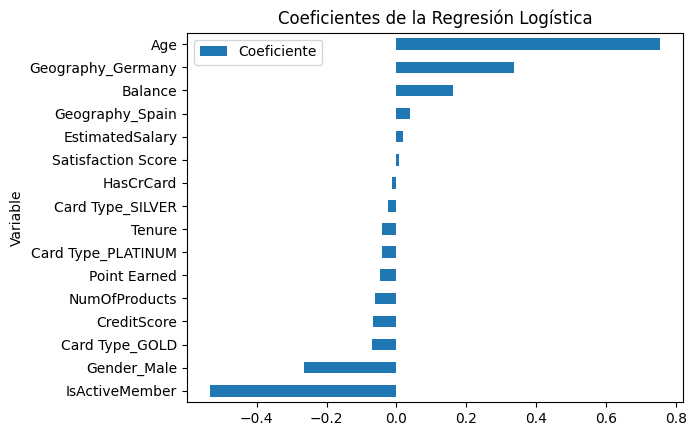

In [ ]:
coeficientes = pd.DataFrame({
    'Variable': X.columns,
    'Coeficiente': modelo.coef_[0]
})

coeficientes.sort_values(
    by='Coeficiente'
).plot(
    x='Variable',
    y='Coeficiente',
    kind='barh'
)

plt.title("Coeficientes de la Regresión Logística")

plt.show()